# Лабораторная работа № 2.1
## Выборочное наблюдение

**Выполнили:**

- Левченков Артемий Викторович;
- Бикбулатова Динара Фануровна;
- Ладыгин Максим Александрович.

**Группа:** БИВТ-24-АЭ-3

Исходные данные - статистика преступлений, зарегистрированных в Москве в 2021 году, распределённых по возрасту преступников.

**Цель работы:** определить необходимый объём повторной выборки, сгенерировать 36 выборок, найти их выборочные средние и построить интервальный ряд распределения этих средних.

### 1. Подготовка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_table("/Users/blx000/PycharmProjects/matstat/data/moscow.txt", header=None)[0]
N = len(data)

print("Количество наблюдений:", N)
print("Минимальный возраст:", data.min())
print("Максимальный возраст:", data.max())


Количество наблюдений: 32423
Минимальный возраст: 14
Максимальный возраст: 73


In [2]:
discrete = data.value_counts().sort_index().rename_axis("x").reset_index(name="n")
discrete["w"] = discrete["n"] / N

print("Дискретный ряд")
display(discrete)


Дискретный ряд


,x,n,w
0,14,49,0.001511
1,15,53,0.001635
2,16,236,0.007279
3,17,126,0.003886
4,18,806,0.024859
5,19,971,0.029948
6,20,910,0.028066
7,21,716,0.022083
8,22,944,0.029115
9,23,1071,0.033032


### 2. Определение объёма повторной выборки

$$
\bar{x}=\sum_{i=1}^{k}x_iw_i,\qquad
\sigma=\sqrt{\sum_{i=1}^{k}(x_i-\bar{x})^2w_i}.
$$

$$
2\Phi(t)=\gamma,\qquad n=\frac{t^2\sigma^2}{\delta^2}.
$$

$\gamma=0{,}95$, $t=1{,}96$, $\delta=3$ года.

In [3]:
from math import ceil, floor

def mean_value(x, n):
    return sum(x * n) / sum(n)

def dispersion(x, n, mean):
    return sum((x - mean) ** 2 * n) / sum(n)


def standard_deviation(D):
    return D ** 0.5


def minimum(x):
    return min(x)


def maximum(x):
    return max(x)


x = discrete["x"]
n = discrete["n"]

mean_d = mean_value(x, n)
D_d = dispersion(x, n, mean_d)
sigma_d = standard_deviation(D_d)

print(f"Средняя: {mean_d:.4f}")
print(f"Дисперсия: {D_d:.4f}")
print(f"Среднее квадратическое отклонение: {sigma_d:.4f}")


Средняя: 35.3730
Дисперсия: 144.9170
Среднее квадратическое отклонение: 12.0381


In [4]:
gamma = 0.95
delta = 3
t = 1.96

n_exact = t ** 2 * sigma_d ** 2 / delta ** 2
sample_size = ceil(n_exact)

print(f"Надёжность: {gamma}")
print(f"Точность: {delta} года")
print(f"Коэффициент доверия: {t}")
print(f"Расчётный объём: {n_exact:.4f}")
print(f"Объём каждой выборки: {sample_size}")


Надёжность: 0.95
Точность: 3 года
Коэффициент доверия: 1.96
Расчётный объём: 61.8570
Объём каждой выборки: 62


### 3. Генерация 36 повторных выборок и расчёт выборочных средних

In [5]:
number_of_samples = 36

sample_means = []

for i in range(number_of_samples):
    sample = data.sample(n=sample_size, replace=True)

    sample_discrete = sample.value_counts().sort_index().rename_axis("x").reset_index(name="n")
    sample_discrete["w"] = sample_discrete["n"] / sample_size

    x = sample_discrete["x"]
    n = sample_discrete["n"]
    sample_mean = mean_value(x, n)
    sample_means.append(sample_mean)

sample_means = pd.Series(sample_means)

means_table = pd.DataFrame({
    "Номер выборки": range(1, number_of_samples + 1),
    "Выборочная средняя": sample_means,
})

display(means_table.round(4))


,Номер выборки,Выборочная средняя
0,1,36.0323
1,2,37.4355
2,3,33.1129
3,4,35.1129
4,5,35.7742
5,6,34.0323
6,7,33.0000
7,8,37.5645
8,9,35.4355
9,10,37.6935


### 4. Интервальный ряд выборочных средних

Левая граница — минимум выборочных средних, округлённый вниз; правая — максимум, округлённый вверх. Шаг — 1 год.

In [6]:
min_mean = minimum(sample_means)
max_mean = maximum(sample_means)
x_min = floor(min_mean)
x_max = ceil(max_mean)

h = 1
k = x_max - x_min
edges = [x_min + i * h for i in range(k + 1)]

rows = []
for i in range(k):
    left = edges[i]
    right = edges[i + 1]

    if i < k - 1:
        n = ((sample_means >= left) & (sample_means < right)).sum()
    else:
        n = ((sample_means >= left) & (sample_means <= right)).sum()

    rows.append([left, right, (left + right) / 2, n])

interval = pd.DataFrame(rows, columns=["x_l", "x_r", "x_middle", "n"])
interval["w"] = interval["n"] / number_of_samples

print(f"Минимальная выборочная средняя: {min_mean:.4f}")
print(f"Максимальная выборочная средняя: {max_mean:.4f}")
print(f"Границы интервального ряда: [{x_min}; {x_max}]")
print(f"Ширина интервала: h = {h}")
display(interval.round(4))
a = 36
print(f"Сумма абсолютных частот: {a}")
print(f"Сумма относительных частот: {interval['w'].sum():.4f}")


Минимальная выборочная средняя: 32.4839
Максимальная выборочная средняя: 38.1129
Границы интервального ряда: [32; 39]
Ширина интервала: h = 1


,x_l,x_r,x_middle,n,w
0,32,33,32.5,1,0.0278
1,33,34,33.5,6,0.1667
2,34,35,34.5,5,0.1389
3,35,36,35.5,12,0.3333
4,36,37,36.5,5,0.1389
5,37,38,37.5,6,0.1667
6,38,39,38.5,1,0.0278


Сумма абсолютных частот: 36
Сумма относительных частот: 1.0000


### 5. Гистограмма относительных частот

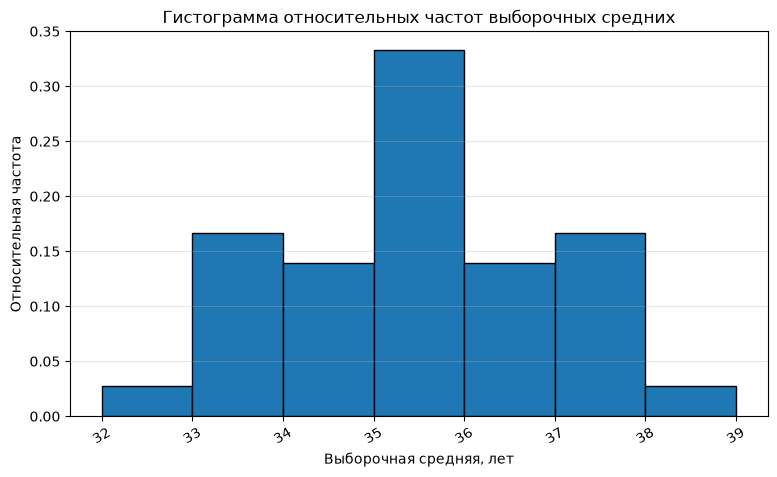

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(interval["x_l"], interval["w"], width=h, align="edge", edgecolor="black")
plt.title("Гистограмма относительных частот выборочных средних")
plt.xlabel("Выборочная средняя, лет")
plt.ylabel("Относительная частота")
plt.xticks(edges, [f"{edge:.0f}" for edge in edges], rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()


### Вывод

По исходным данным объём генеральной совокупности составляет 32 423 наблюдения. Средний возраст равен $35{,}3730$ года, дисперсия — $144{,}9170$, среднее квадратическое отклонение — $12{,}0381$ года. Эти характеристики рассчитаны по дискретному ряду с использованием частот каждого возраста.

При надёжности $\gamma=0{,}95$ и допустимой погрешности оценки среднего $\delta=3$ года по формуле лекции для повторной выборки получен расчётный объём $n\approx61{,}8570$. Использован коэффициент $t=1{,}96$. После округления вверх принят объём одной выборки $n=62$.

Из генеральной совокупности сформированы 36 случайных повторных выборок по 62 наблюдения. Для каждой рассчитана выборочная средняя. При новом запуске выполняется новый случайный отбор, поэтому конкретные средние, крайние значения и частоты интервалов могут изменяться. Объём выборок остаётся равным 62, поскольку исходные данные, надёжность и точность не меняются.

По полученным средним построен интервальный ряд с шагом 1 год. Его левая граница определяется округлением минимальной выборочной средней вниз, правая — округлением максимальной средней вверх. Каждый результат отнесён к одному интервалу; последний интервал включает правую границу. Относительные частоты получены делением частот интервалов на 36. В таблице представлены границы, середины интервалов, абсолютные и относительные частоты.

Гистограмма показывает распределение 36 выборочных средних. Высота каждого столбца равна доле средних в соответствующем интервале шириной 1 год. Конкретный вид гистограммы зависит от случайного отбора. Таким образом, рассчитан необходимый объём повторной выборки, получены 36 выборочных средних и построены их интервальный ряд, относительные частоты и гистограмма.